# Phase 1 — Data Inspection & Pre-processing

Binary classification of two Ethiopian Kiñit scales, **Tizita vs. Bati**, on the EMIR dataset.

This notebook loads the raw audio, inspects it, and applies the pre-processing pipeline:
**resample to 16 kHz mono → DC-offset removal → pre-emphasis → peak normalisation**.

**Key finding:** although documented as 16 kHz, the EMIR files are a mix of 16 kHz and 44.1 kHz, so standardisation is required.

## Setup
Place the EMIR Tizita/Bati clips in `data/raw/tizita/` and `data/raw/bati/`.

In [1]:
import numpy as np
import librosa
import librosa.display
import matplotlib.pyplot as plt
from pathlib import Path

# Anchor to project root: works whether run from repo root or notebooks/.
# Figures/features go to the SHARED root folders (same as the src/ scripts).
ROOT = Path.cwd()
if ROOT.name == 'notebooks':
    ROOT = ROOT.parent
RAW  = ROOT / 'data' / 'raw'
FEAT = ROOT / 'features'; FEAT.mkdir(exist_ok=True)
FIG  = ROOT / 'figures';  FIG.mkdir(exist_ok=True)
SR = 16000          # target sample rate (mono)

## 1.1  Inspect raw sample rates
Verify the documented 16 kHz claim by reading the native sample rate of each file.

In [2]:
from collections import Counter
rates = Counter()
RAW = Path('../data/raw')    
for scale in ['tizita', 'bati']:
    for wav in sorted((RAW / scale).glob('*.wav')):
        sr = librosa.get_samplerate(wav)
        rates[sr] += 1
print('Native sample rates across the dataset:')
for sr, n in rates.items():
    print(f'  {sr} Hz : {n} files')

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Native sample rates across the dataset:
  16000 Hz : 63 files
  44100 Hz : 243 files


## 1.2  Pre-processing pipeline
- **DC-offset removal**: subtract the mean so the waveform is centred on zero.
- **Pre-emphasis** (α = 0.97): a high-pass-like filter that boosts weak high frequencies so they are not drowned out.
- **Peak normalisation**: scale so the loudest sample is ±1, removing volume differences between clips.

In [3]:
def preprocess(path, sr=SR, pre_emph=0.97):
    # load + resample to mono 16 kHz
    y, _ = librosa.load(path, sr=sr, mono=True)
    # DC-offset removal
    y = y - np.mean(y)
    # pre-emphasis
    y = np.append(y[0], y[1:] - pre_emph * y[:-1])
    # peak normalisation
    peak = np.max(np.abs(y))
    if peak > 0:
        y = y / peak
    return y

# quick check on one clip
example = next((RAW / 'tizita').glob('*.wav'))
y = preprocess(example)
print('processed mean (~0):', float(np.mean(y)))
print('processed peak (1.0):', float(np.max(np.abs(y))))
print('samples:', len(y), '| duration (s):', len(y) / SR)

processed mean (~0): 4.3693569296010537e-07
processed peak (1.0): 1.0
samples: 480000 | duration (s): 30.0


## 1.3  Load the full dataset
Returns the processed signals and aligned labels (0 = bati, 1 = tizita).

In [4]:
def load_dataset(raw=RAW):
    signals, labels, names = [], [], []
    for label, scale in enumerate(['bati', 'tizita']):  # bati=0, tizita=1
        for wav in sorted((raw / scale).glob('*.wav')):
            signals.append(preprocess(wav))
            labels.append(scale)
            names.append(wav.name)
    return signals, np.array(labels), names

signals, y, names = load_dataset()
print('clips:', len(signals))
import collections
print('per class:', dict(collections.Counter(y)))

clips: 306
per class: {np.str_('bati'): 144, np.str_('tizita'): 162}


## 1.4  Waveform vs. spectrogram
A waveform shows amplitude over *time* — you cannot see pitch. A scale is a *frequency* property, so we need the spectrogram (STFT) to see harmonic structure. The differing high-frequency bandwidth between clips reveals the **recording confound**.

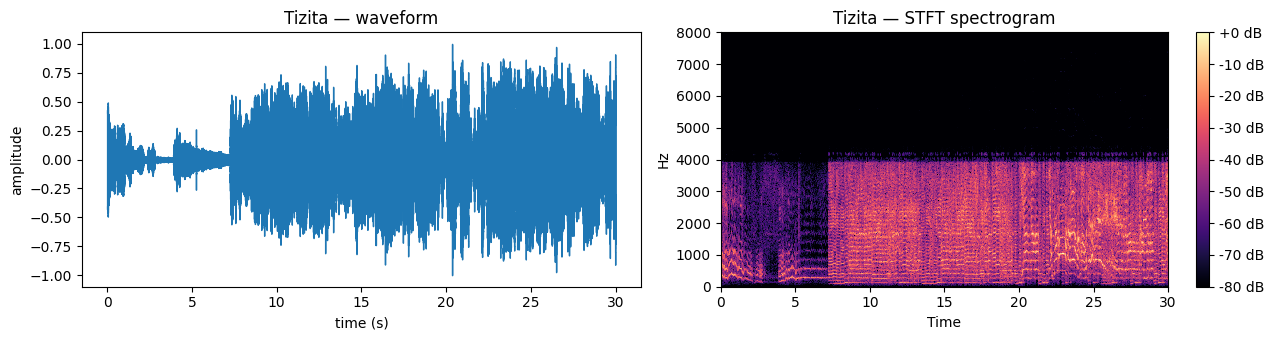

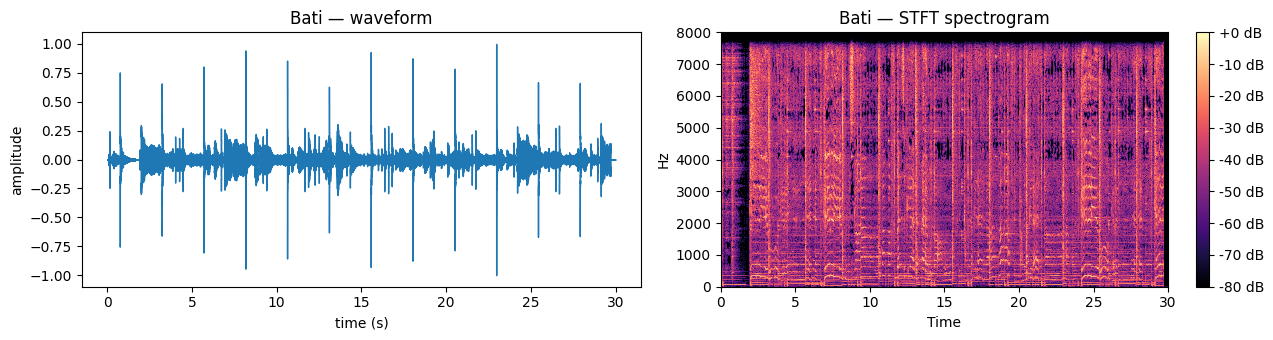

In [5]:
def show_waveform_and_spectrogram(y, title):
    fig, ax = plt.subplots(1, 2, figsize=(13, 3.5))
    librosa.display.waveshow(y, sr=SR, ax=ax[0])
    ax[0].set(title=f'{title} — waveform', xlabel='time (s)', ylabel='amplitude')
    D = librosa.amplitude_to_db(np.abs(librosa.stft(y, n_fft=2048, hop_length=512)), ref=np.max)
    img = librosa.display.specshow(D, sr=SR, hop_length=512, x_axis='time', y_axis='hz', ax=ax[1])
    ax[1].set(title=f'{title} — STFT spectrogram')
    fig.colorbar(img, ax=ax[1], format='%+2.0f dB')
    plt.tight_layout()
    return fig

ti = signals[list(y).index('tizita')]
ba = signals[list(y).index('bati')]
show_waveform_and_spectrogram(ti, 'Tizita'); plt.savefig(FIG/'wave_spec_tizita.png', dpi=150)
show_waveform_and_spectrogram(ba, 'Bati');   plt.savefig(FIG/'wave_spec_bati.png', dpi=150)
plt.show()

---
**Next:** Phase 2 — feature extraction (log-Mel, MFCC + CMN, chroma).